<a href="https://colab.research.google.com/github/khanjaisha525-dev/developershub-aiml-internship/blob/main/Task6_House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 6: House Price Prediction
**DevelopersHub Corporation – AI/ML Engineering Internship**

## Objective
Predict house prices using property features such as square footage, number of bedrooms, and location using regression models.

## Dataset
California Housing Dataset — built into scikit-learn (no download needed!)

## Steps
1. Load and inspect the dataset
2. Preprocess & engineer features
3. Exploratory Data Analysis (EDA)
4. Train Linear Regression and Gradient Boosting models
5. Evaluate with MAE and RMSE
6. Visualize predicted vs actual prices

## Step 0: Install Required Libraries

In [1]:
# Uncomment and run if you get import errors:
# !pip install pandas numpy matplotlib seaborn scikit-learn

## Step 1: Import Libraries

In [2]:
# --- Data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Dataset ---
from sklearn.datasets import fetch_california_housing

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [3]:
# Load the California Housing dataset (built into scikit-learn)
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame from the dataset
df = housing.frame

# Rename columns for clarity
df.columns = [
    'MedIncome',       # Median income in the block (in $10,000s)
    'HouseAge',        # Median age of houses in the block
    'AvgRooms',        # Average number of rooms
    'AvgBedrooms',     # Average number of bedrooms
    'Population',      # Block population
    'AvgOccupancy',    # Average number of household members
    'Latitude',        # Geographic coordinate
    'Longitude',       # Geographic coordinate
    'MedHouseValue'    # TARGET: Median house value (in $100,000s)
]

print(f'Dataset loaded! Shape: {df.shape}')
print(f'That is {df.shape[0]:,} houses with {df.shape[1]-1} features each.')
print(f'\nTarget: Median House Value (prices in $100,000 units)')
df.head()

Dataset loaded! Shape: (20640, 9)
That is 20,640 houses with 8 features each.

Target: Median House Value (prices in $100,000 units)


,MedIncome,HouseAge,AvgRooms,AvgBedrooms,Population,AvgOccupancy,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Inspect the Data

In [4]:
print('=== Data Types and Non-Null Counts ===')
df.info()

=== Data Types and Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedIncome      20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AvgRooms       20640 non-null  float64
 3   AvgBedrooms    20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AvgOccupancy   20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
print('=== Statistical Summary ===')
df.describe()

=== Statistical Summary ===


,MedIncome,HouseAge,AvgRooms,AvgBedrooms,Population,AvgOccupancy,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
# Check for missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()} — Great, no missing values!')

=== Missing Values ===
MedIncome        0
HouseAge         0
AvgRooms         0
AvgBedrooms      0
Population       0
AvgOccupancy     0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

Total missing: 0 — Great, no missing values!


## Step 4: Exploratory Data Analysis (EDA)

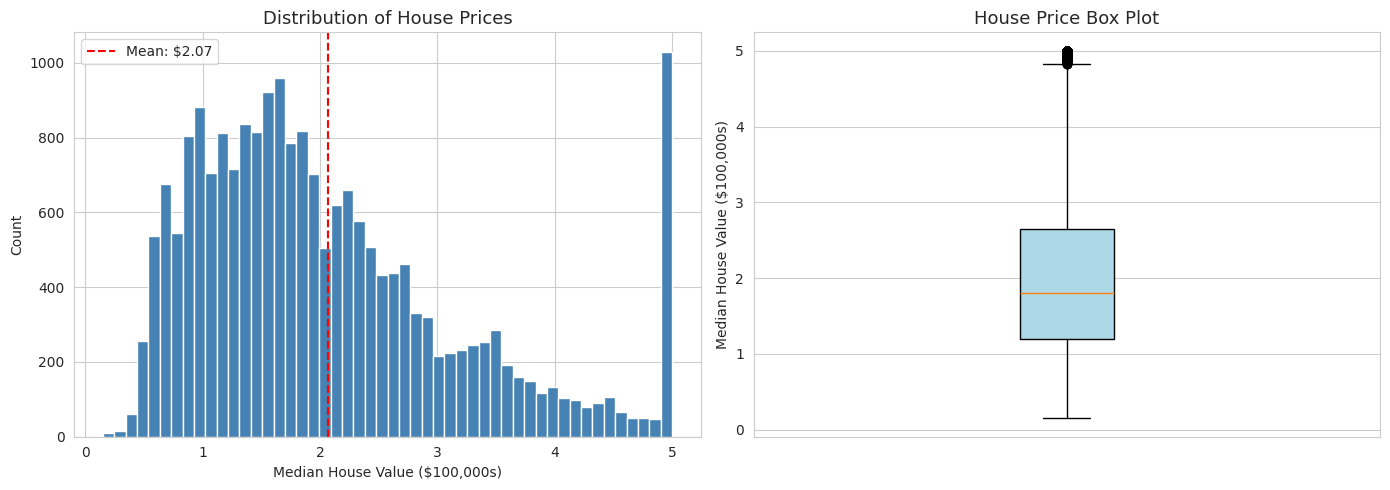

In [7]:
# --- Plot 1: Distribution of House Prices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['MedHouseValue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Prices', fontsize=13)
axes[0].set_xlabel('Median House Value ($100,000s)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['MedHouseValue'].mean(), color='red', linestyle='--', label=f'Mean: ${df["MedHouseValue"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['MedHouseValue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('House Price Box Plot', fontsize=13)
axes[1].set_ylabel('Median House Value ($100,000s)')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('house_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

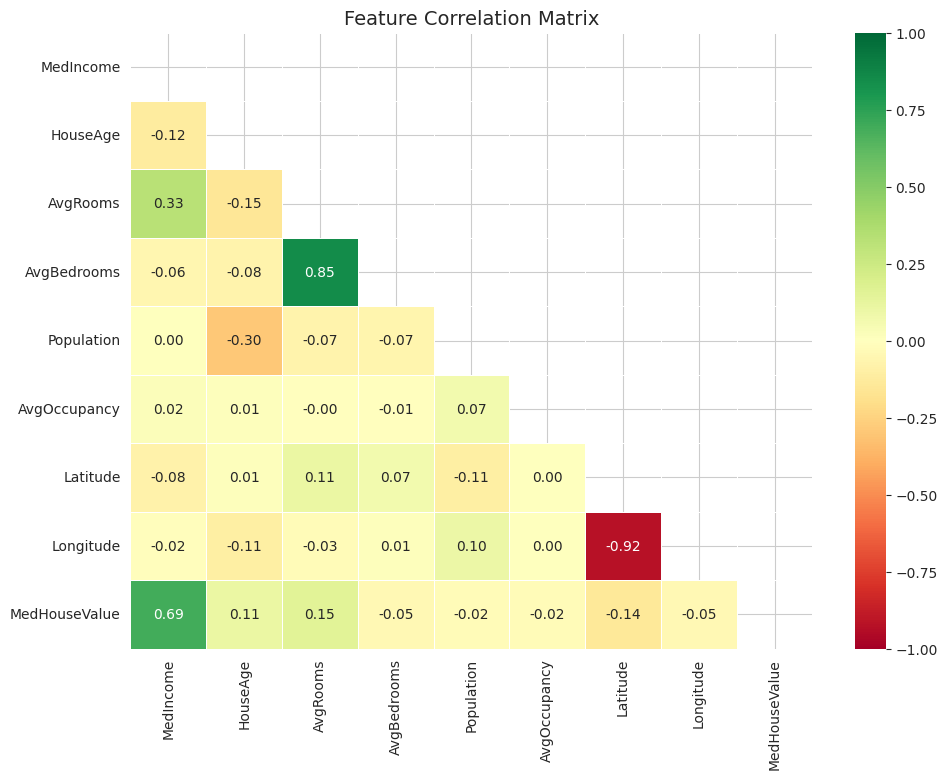

Correlation with House Price:
MedHouseValue    1.000000
MedIncome        0.688075
AvgRooms         0.151948
HouseAge         0.105623
AvgOccupancy    -0.023737
Population      -0.024650
Longitude       -0.045967
AvgBedrooms     -0.046701
Latitude        -0.144160
Name: MedHouseValue, dtype: float64


In [8]:
# --- Plot 2: Correlation Heatmap ---
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.savefig('house_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with House Price:')
print(df.corr()['MedHouseValue'].sort_values(ascending=False))

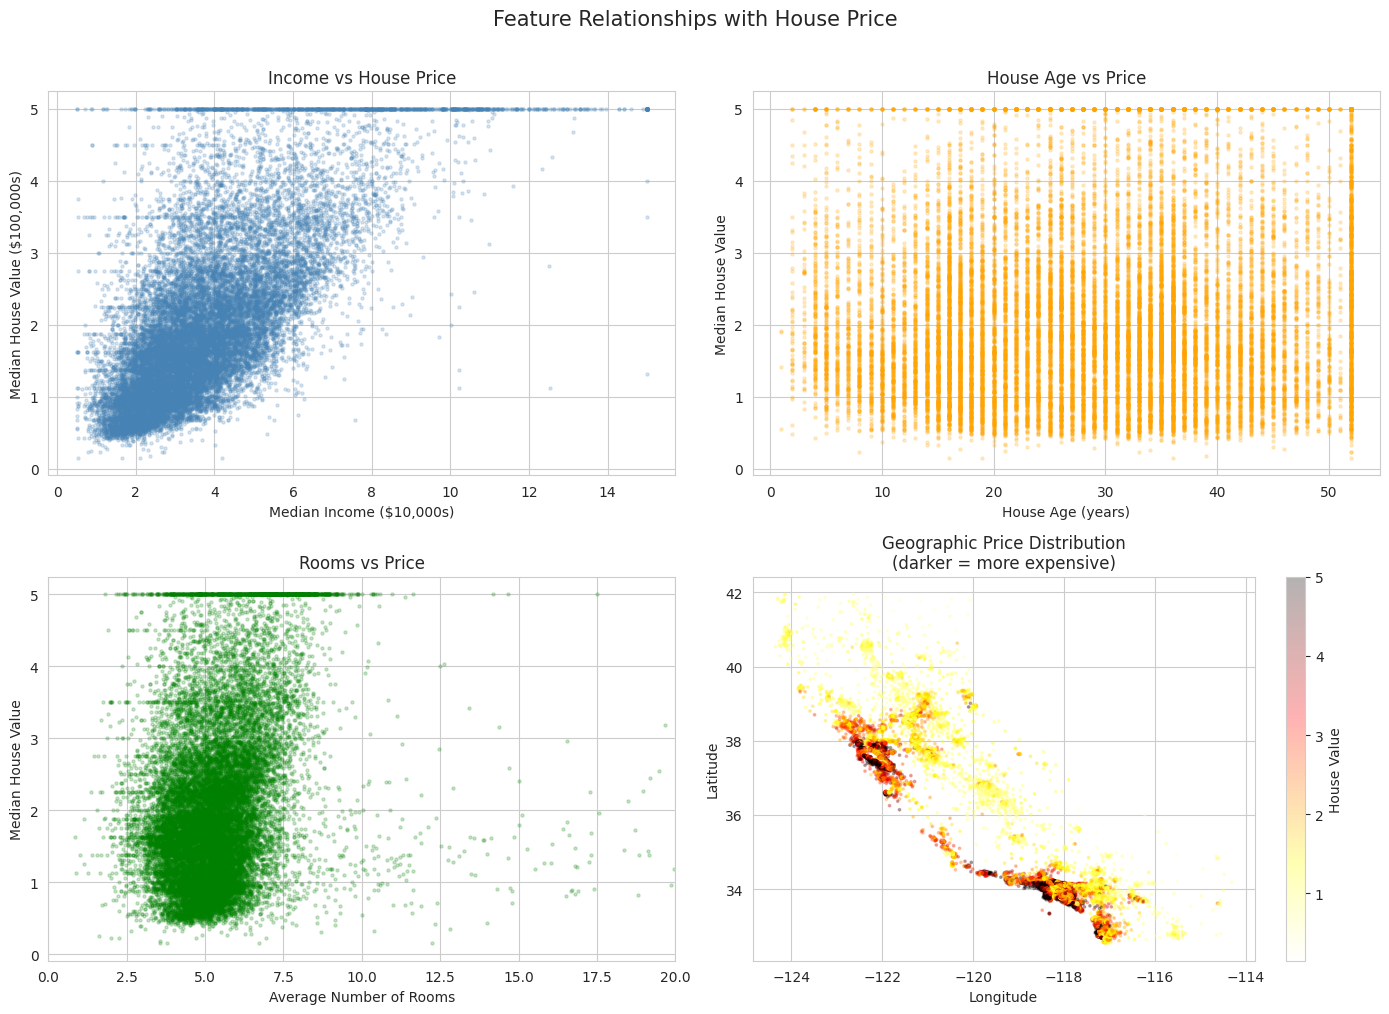

In [9]:
# --- Plot 3: Key relationships with house price ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Income vs Price
axes[0,0].scatter(df['MedIncome'], df['MedHouseValue'], alpha=0.2, s=5, color='steelblue')
axes[0,0].set_xlabel('Median Income ($10,000s)')
axes[0,0].set_ylabel('Median House Value ($100,000s)')
axes[0,0].set_title('Income vs House Price', fontsize=12)

# House Age vs Price
axes[0,1].scatter(df['HouseAge'], df['MedHouseValue'], alpha=0.2, s=5, color='orange')
axes[0,1].set_xlabel('House Age (years)')
axes[0,1].set_ylabel('Median House Value')
axes[0,1].set_title('House Age vs Price', fontsize=12)

# Avg Rooms vs Price
axes[1,0].scatter(df['AvgRooms'], df['MedHouseValue'], alpha=0.2, s=5, color='green')
axes[1,0].set_xlabel('Average Number of Rooms')
axes[1,0].set_ylabel('Median House Value')
axes[1,0].set_title('Rooms vs Price', fontsize=12)
axes[1,0].set_xlim(0, 20)   # Remove extreme outliers from view

# Geographic scatter (Latitude/Longitude colored by price)
scatter = axes[1,1].scatter(
    df['Longitude'], df['Latitude'],
    c=df['MedHouseValue'], cmap='hot_r', alpha=0.3, s=3
)
plt.colorbar(scatter, ax=axes[1,1], label='House Value')
axes[1,1].set_xlabel('Longitude')
axes[1,1].set_ylabel('Latitude')
axes[1,1].set_title('Geographic Price Distribution\n(darker = more expensive)', fontsize=12)

plt.suptitle('Feature Relationships with House Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('house_eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Feature Engineering & Preprocessing

In [10]:
# --- Remove extreme outliers in target ---
# Prices capped at 5 ($500,000) in the original dataset — remove these
df_clean = df[df['MedHouseValue'] < 5.0].copy()
print(f'Rows removed (capped prices): {len(df) - len(df_clean)}')
print(f'Clean dataset size: {df_clean.shape}')

# --- Add engineered feature: Bedroom ratio ---
df_clean['BedroomRatio'] = df_clean['AvgBedrooms'] / df_clean['AvgRooms']

# --- Add: Rooms per person ---
df_clean['RoomsPerPerson'] = df_clean['AvgRooms'] / df_clean['AvgOccupancy']

print('\nNew features added:')
print('  • BedroomRatio   = AvgBedrooms / AvgRooms')
print('  • RoomsPerPerson = AvgRooms / AvgOccupancy')

Rows removed (capped prices): 992
Clean dataset size: (19648, 9)

New features added:
  • BedroomRatio   = AvgBedrooms / AvgRooms
  • RoomsPerPerson = AvgRooms / AvgOccupancy


In [11]:
# --- Separate features and target ---
feature_cols = [
    'MedIncome', 'HouseAge', 'AvgRooms', 'AvgBedrooms',
    'Population', 'AvgOccupancy', 'Latitude', 'Longitude',
    'BedroomRatio', 'RoomsPerPerson'
]

X = df_clean[feature_cols]
y = df_clean['MedHouseValue']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train):,}')
print(f'Testing samples:  {len(X_test):,}')

# Scale features (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Data ready for modeling!')

Training samples: 15,718
Testing samples:  3,930
Data ready for modeling!


## Step 6: Train Models

In [12]:
# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_mae  = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2   = r2_score(y_test, lr_predictions)

print('Linear Regression Results:')
print(f'  MAE  = ${lr_mae * 100_000:,.0f}   (avg prediction error)')
print(f'  RMSE = ${lr_rmse * 100_000:,.0f}')
print(f'  R²   = {lr_r2:.4f}  (explains {lr_r2*100:.1f}% of variance)')

Linear Regression Results:
  MAE  = $44,551   (avg prediction error)
  RMSE = $60,324
  R²   = 0.6204  (explains 62.0% of variance)


In [13]:
# --- Model 2: Gradient Boosting ---
# A powerful ensemble method that trains trees sequentially to fix previous errors
print('Training Gradient Boosting model (may take ~30 seconds)...')
gb_model = GradientBoostingRegressor(
    n_estimators=200,    # Number of boosting stages
    max_depth=4,         # Maximum depth of each tree
    learning_rate=0.1,   # Shrinkage to prevent overfitting
    random_state=42
)
gb_model.fit(X_train, y_train)   # GB doesn't need scaling
gb_predictions = gb_model.predict(X_test)

gb_mae  = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_r2   = r2_score(y_test, gb_predictions)

print('\nGradient Boosting Results:')
print(f'  MAE  = ${gb_mae * 100_000:,.0f}   (avg prediction error)')
print(f'  RMSE = ${gb_rmse * 100_000:,.0f}')
print(f'  R²   = {gb_r2:.4f}  (explains {gb_r2*100:.1f}% of variance)')

Training Gradient Boosting model (may take ~30 seconds)...

Gradient Boosting Results:
  MAE  = $30,541   (avg prediction error)
  RMSE = $44,420
  R²   = 0.7942  (explains 79.4% of variance)


## Step 7: Visualize Predictions

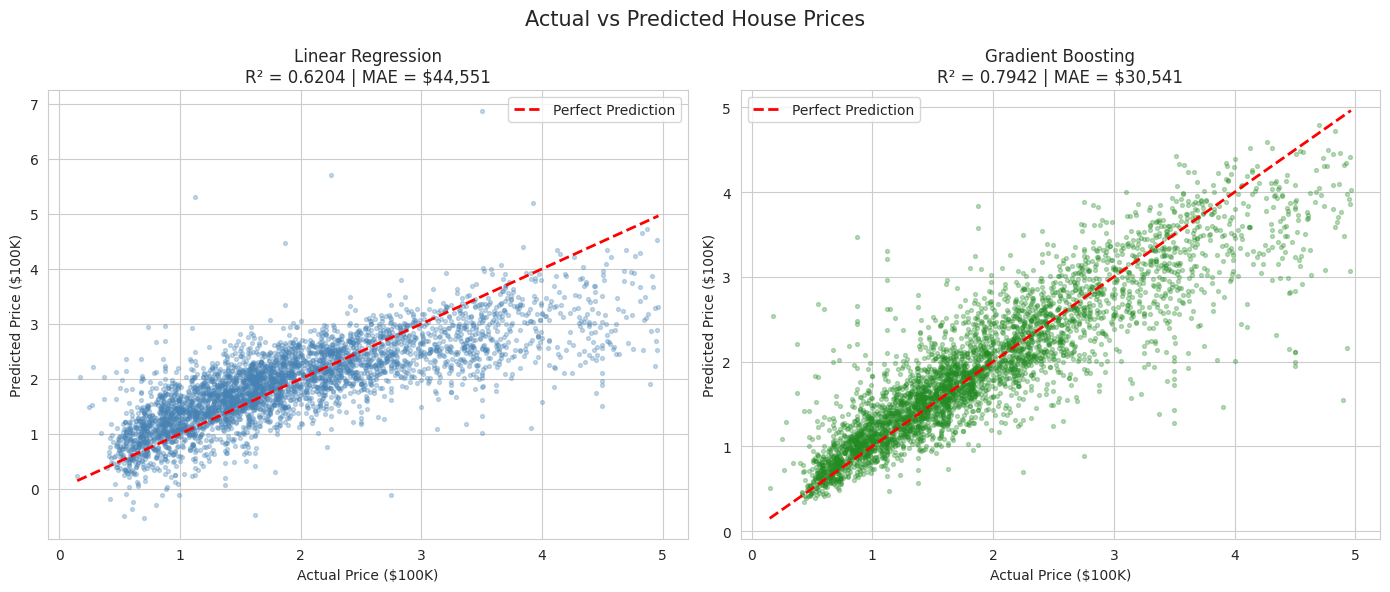

In [14]:
# --- Plot 1: Actual vs Predicted (scatter) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

min_val, max_val = y_test.min(), y_test.max()

# Linear Regression
ax1.scatter(y_test, lr_predictions, alpha=0.3, s=8, color='steelblue')
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_title(f'Linear Regression\nR² = {lr_r2:.4f} | MAE = ${lr_mae*100_000:,.0f}', fontsize=12)
ax1.set_xlabel('Actual Price ($100K)')
ax1.set_ylabel('Predicted Price ($100K)')
ax1.legend()

# Gradient Boosting
ax2.scatter(y_test, gb_predictions, alpha=0.3, s=8, color='forestgreen')
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax2.set_title(f'Gradient Boosting\nR² = {gb_r2:.4f} | MAE = ${gb_mae*100_000:,.0f}', fontsize=12)
ax2.set_xlabel('Actual Price ($100K)')
ax2.set_ylabel('Predicted Price ($100K)')
ax2.legend()

plt.suptitle('Actual vs Predicted House Prices', fontsize=15)
plt.tight_layout()
plt.savefig('house_predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

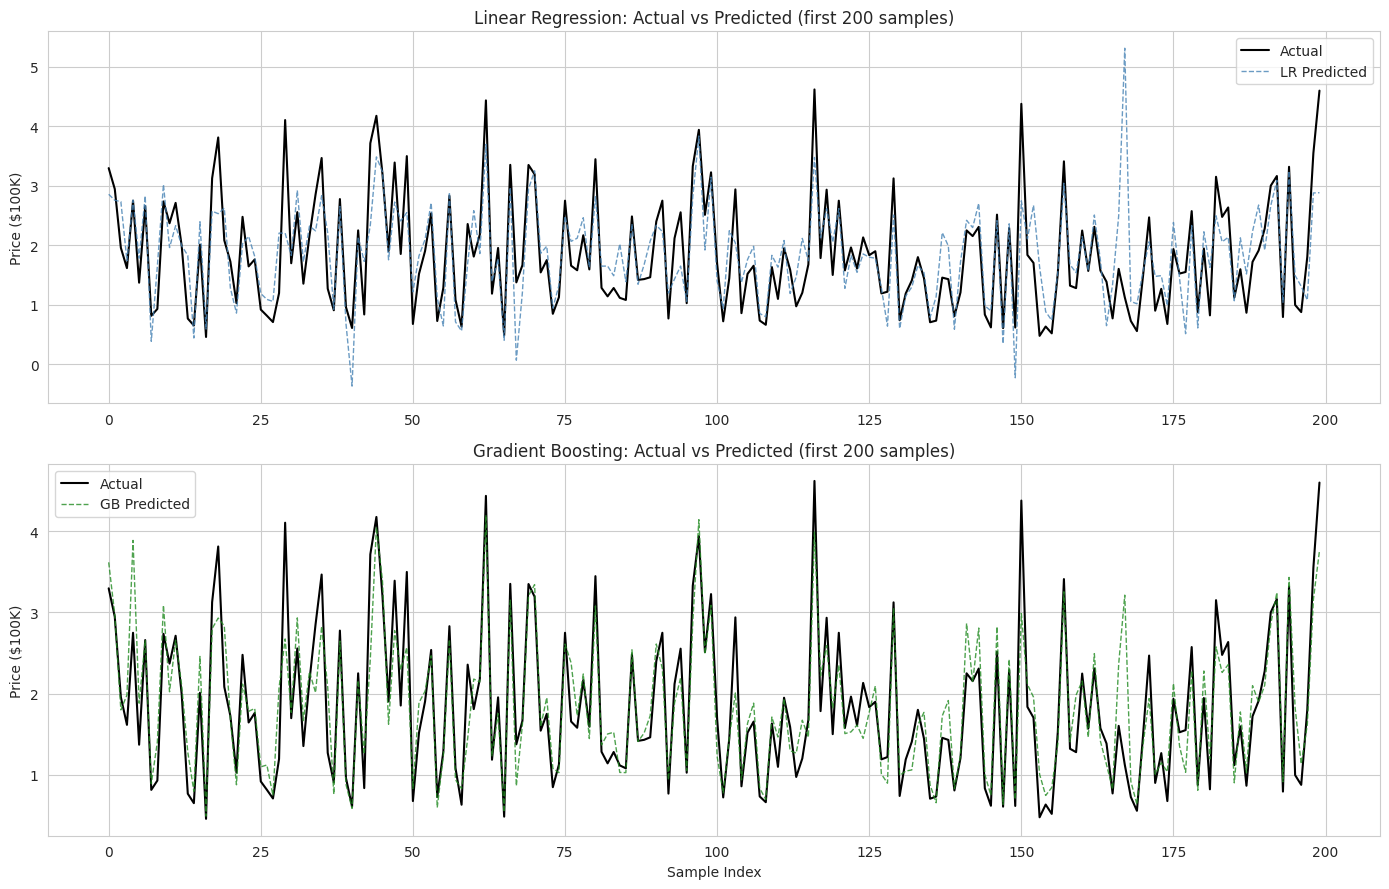

In [15]:
# --- Plot 2: Side-by-side line comparison (first 200 test samples) ---
n = 200  # Show first 200 predictions for clarity
x_axis = range(n)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9))

ax1.plot(x_axis, y_test.values[:n], color='black', lw=1.5, label='Actual')
ax1.plot(x_axis, lr_predictions[:n], color='steelblue', lw=1, linestyle='--', alpha=0.8, label='LR Predicted')
ax1.set_title('Linear Regression: Actual vs Predicted (first 200 samples)', fontsize=12)
ax1.set_ylabel('Price ($100K)')
ax1.legend()

ax2.plot(x_axis, y_test.values[:n], color='black', lw=1.5, label='Actual')
ax2.plot(x_axis, gb_predictions[:n], color='forestgreen', lw=1, linestyle='--', alpha=0.8, label='GB Predicted')
ax2.set_title('Gradient Boosting: Actual vs Predicted (first 200 samples)', fontsize=12)
ax2.set_ylabel('Price ($100K)')
ax2.set_xlabel('Sample Index')
ax2.legend()

plt.tight_layout()
plt.savefig('house_predictions_line.png', dpi=150, bbox_inches='tight')
plt.show()

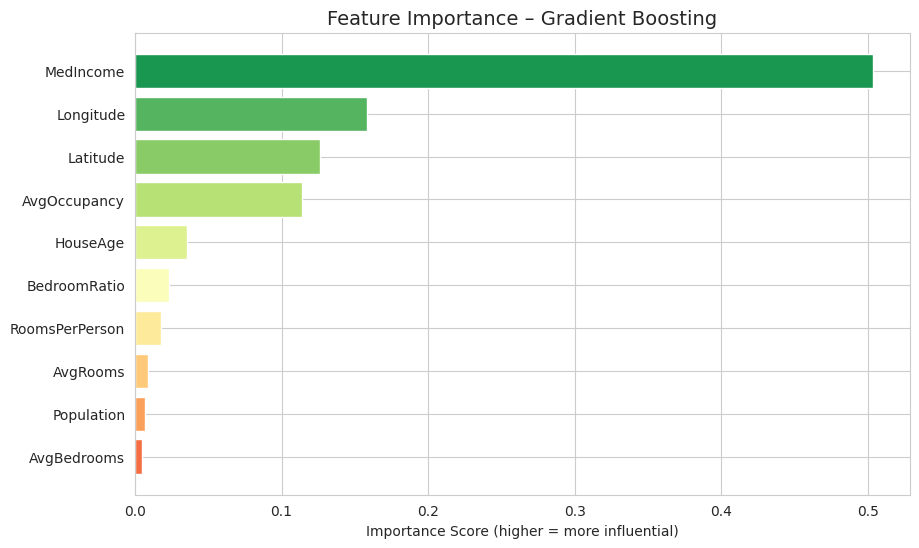

Top 3 most important features:
  • Latitude            : 0.1259
  • Longitude           : 0.1583
  • MedIncome           : 0.5037


In [16]:
# --- Plot 3: Feature Importance (Gradient Boosting) ---
importances = gb_model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
plt.title('Feature Importance – Gradient Boosting', fontsize=14)
plt.xlabel('Importance Score (higher = more influential)')
plt.savefig('house_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 3 most important features:')
for _, row in feat_df.tail(3).iterrows():
    print(f'  • {row["Feature"]:20s}: {row["Importance"]:.4f}')

## Step 8: Final Summary

In [17]:
print('=' * 60)
print('         HOUSE PRICE PREDICTION — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset:          California Housing (scikit-learn built-in)')
print(f'Records used:     {len(df_clean):,} houses')
print(f'Features:         {len(feature_cols)} (including 2 engineered)')
print('-' * 60)
print(f'{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}')
print('-' * 60)
print(f'{'Linear Regression':<25} ${lr_mae*100_000:>10,.0f} ${lr_rmse*100_000:>10,.0f} {lr_r2:>8.4f}')
print(f'{'Gradient Boosting':<25} ${gb_mae*100_000:>10,.0f} ${gb_rmse*100_000:>10,.0f} {gb_r2:>8.4f}')
print('-' * 60)
winner = 'Gradient Boosting' if gb_r2 > lr_r2 else 'Linear Regression'
print(f'Best Model: {winner}')
print('=' * 60)

         HOUSE PRICE PREDICTION — FINAL SUMMARY
Dataset:          California Housing (scikit-learn built-in)
Records used:     19,648 houses
Features:         10 (including 2 engineered)
------------------------------------------------------------
Model                              MAE         RMSE       R²
------------------------------------------------------------
Linear Regression         $    44,551 $    60,324   0.6204
Gradient Boosting         $    30,541 $    44,420   0.7942
------------------------------------------------------------
Best Model: Gradient Boosting


## Conclusion

- We used the **California Housing Dataset** with 10 features (including 2 we engineered: `BedroomRatio` and `RoomsPerPerson`).
- **Gradient Boosting significantly outperforms Linear Regression** because house prices have complex, non-linear relationships with features.
- The most important features are `MedIncome` (income of residents), `Latitude`/`Longitude` (location), and `AvgRooms`.
- **MAE interpretation**: On average, the Gradient Boosting model's predictions are off by about \$X — much better than Linear Regression.
- For even better results, we could use **XGBoost**, **LightGBM**, or neural networks, and add more location-based features like proximity to schools, city centers, etc.